# Taller Computacional C1
### Escalamiento y análisis dimensional: **medición experimental de tiempo y memoria de algoritmos**
---

#### La idea central

En el laboratorio de física ustedes miden el periodo de un péndulo para distintas longitudes y descubren que $T \propto L^{1/2}$. Ese exponente no se "demuestra" con el cronómetro: se **mide**, con incertidumbre, y luego se **contrasta** con el modelo teórico.

Hoy el sistema físico bajo estudio es **el computador**, y las magnitudes observables son el **tiempo de ejecución** $t$ y la **memoria** $M$. La hipótesis de trabajo es una ley de potencias idéntica en forma a la del péndulo:

$$ t(n) = C\,n^{k} \qquad \Longrightarrow \qquad \log t = \log C + k\log n $$

donde $n$ es el tamaño de la entrada. El exponente $k$ es lo que en Ciencias de la Computación se llama **complejidad asintótica** (la $k$ de $O(n^k)$), y la constante $C$ es una propiedad de *esta* máquina, con unidades de **segundos por operación**.

In [ ]:
#  Configuración e identificación del "aparato experimental"

import sys
import platform
import time
import gc
import tracemalloc
import statistics
import base64

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.2)
plt.rcParams["text.usetex"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(42)


# Repeticiones por medición
REPETICIONES = 5


print("Identificación del sistema")
print("-" * 52)
print(f"Python           : {sys.version.split()[0]}")
print(f"Sistema operativo: {platform.system()} {platform.release()}")
print(f"Procesador       : {platform.processor() or 'no reportado'}")
print(f"Arquitectura     : {platform.machine()}")
print(f"NumPy            : {np.__version__}")
print(f"Resolución del reloj perf_counter: {time.get_clock_info('perf_counter').resolution:.2e} s")

Identificación del sistema
----------------------------------------------------
Python           : 3.11.15
Sistema operativo: Darwin 25.5.0
Procesador       : arm
Arquitectura     : arm64
NumPy            : 2.2.5
Resolución del reloj perf_counter: 4.17e-08 s


## 1. Protocolo de medición: el cronómetro y sus errores

Medir un tiempo de ejecución **no** es llamar al reloj dos veces. El computador es un sistema con ruido, y ese ruido tiene una estructura muy particular que conviene entender antes de tomar el primer dato:

| Fuente de error | Naturaleza | Mitigación |
|---|---|---|
| Resolución finita del reloj | Sistemático (truncamiento) | Medir bloques con $t \gtrsim 10^{4}\times$ la resolución |
| Planificador del SO, otros procesos | Aleatorio, **asimétrico** (solo suma tiempo) | Repetir y tomar la **mediana** o el mínimo |
| Recolector de basura de Python | Aleatorio, esporádico | Desactivarlo durante la medición |
| Cachés fríos, JIT, primera llamada | Sistemático, decreciente | Ejecutar iteraciones de **calentamiento** |


> **Punto clave, y es de física experimental pura:** el ruido temporal es **estrictamente positivo**. Una interrupción del sistema operativo solo puede hacer que el algoritmo tarde *más*, nunca menos. La distribución de $t$ es asimétrica con cola a la derecha, así que **el promedio es un mal estimador**: se contamina con los valores atípicos. Usaremos la **mediana** como valor central y la **desviación absoluta mediana (MAD)** como dispersión.

In [35]:
#  Instrumento 1: cronómetro robusto
def medir_tiempo(funcion, repeticiones=REPETICIONES, calentamiento=1):
    """
    Mide el tiempo de ejecución de `funcion` (invocable sin argumentos).

    Devuelve (mediana, MAD, minimo) en segundos.

    - `calentamiento`: ejecuciones descartadas (llenan cachés, resuelven
      importaciones perezosas, estabilizan la frecuencia del procesador).
    - Se desactiva el recolector de basura para eliminar una fuente de
      ruido esporádico no correlacionada con el algoritmo.
    """
    for _ in range(calentamiento):
        funcion()

    muestras = []
    gc.disable()
    try:
        for _ in range(repeticiones):
            t0 = time.perf_counter()      
            funcion()
            t1 = time.perf_counter()
            muestras.append(t1 - t0)
    finally:
        gc.enable()

    mediana = statistics.median(muestras)
    mad = statistics.median([abs(t - mediana) for t in muestras])
    return mediana, mad, min(muestras)


#  Instrumento 2: medidor de memoria
def medir_memoria(funcion):
    """
    Mide el pico de memoria adicional (bytes) que ocupa `funcion`.

    `tracemalloc` instrumenta el asignador de memoria del intérprete y
    también rastrea las asignaciones de NumPy, de modo que sirve tanto
    para objetos de Python como para arreglos numéricos.
    """
    gc.collect()
    tracemalloc.start()
    base_actual, _ = tracemalloc.get_traced_memory()
    tracemalloc.reset_peak()
    resultado = funcion()
    actual, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    del resultado
    
    return pico - base_actual


#  Análisis: ajuste de ley de potencias t = C * n^k
def ajustar_ley_potencia(ns, ts, n_min=0):
    """
    Ajusta log(t) = log(C) + k*log(n) por mínimos cuadrados.

    `n_min` define el inicio del RÉGIMEN ASINTÓTICO: los puntos con
    n < n_min se excluyen porque están dominados por costos fijos
    (overhead) y no por el escalamiento del algoritmo.

    Devuelve (k, sigma_k, C).
    """
    ns = np.asarray(ns, dtype=float)
    ts = np.asarray(ts, dtype=float)
    
    mascara = ns >= n_min
    if mascara.sum() < 3:
        raise ValueError("Se requieren al menos 3 puntos en el régimen asintótico.")

    coef, cov = np.polyfit(np.log(ns[mascara]), np.log(ts[mascara]), 1, cov=True)
    k = coef[0]
    sigma_k = float(np.sqrt(cov[0, 0]))
    C = float(np.exp(coef[1]))
    return k, sigma_k, C


## 2. Ejemplo 1 — Escalamiento **temporal**: midiendo el exponente de cuatro algoritmos

Aplicamos el protocolo a cuatro rutinas cuya complejidad teórica conocemos. Esto es el equivalente a calibrar un instrumento con patrones conocidos antes de medir algo desconocido.

| Algoritmo | Operación | Predicción teórica |
|---|---|---|
| A | Suma acumulada con bucle de Python | $O(n)$, $k=1$ |
| B | Ordenamiento (`sorted`, Timsort) | $O(n\log n)$, $k \approx 1.05$–$1.15$ |
| C | Producto matriz–vector (NumPy) | $O(n^2)$, $k=2$ |
| D | Producto matriz–matriz (NumPy/BLAS) | $O(n^3)$, $k=3$ |

Nótese que $n\log n$ **no** es una ley de potencias. Sobre un rango finito de $n$ se comporta como $n^{k}$ con un $k$ ligeramente mayor que 1 — exactamente el mismo fenómeno que ajustar una recta a una curva suave en un intervalo corto. Es un buen recordatorio de que *el modelo es una aproximación válida en un dominio*.

## Notación _Big O_
la notación _Big O_ es una forma de describir el comportamiento asintótico de una función, es decir, cómo crece la función cuando el tamaño de la entrada tiende a infinito. Por ejemplo, si tenemos una función $f(n) = 2n + 1$, entonces $f(n) = O(n)$, ya que la función crece linealmente con el tamaño de la entrada.

## Definición _Big O_

Dadas 2 funciones $f(n)$ y $g(n)$, decimos que $f(n)$ es $O(g(n))$ si existen constantes $c > 0$ y $n_0 \geq 0$ tales que $f(n) \leq c\times g(n)$ para todos los $n \geq n_0$. En términos simples, $f(n)$ es $O(g(n))$ si $f(n)$ crece no más rápido que $c\times g(n)$ para todos los $n \geq n_0$ donde $c$ y $n_0$ son constantes.

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20240329121512/big-o-image.webp" width="600" style="display: block; margin-left: auto; margin-right: auto;">


In [51]:
# Definición de las cargas de trabajo

def carga_suma_python(n):
    datos = list(range(n))
    def tarea():
        #TODO: tarea
        pass
    return tarea

def carga_ordenamiento(n):
    datos = rng.random(n).tolist()
    def tarea():
        #TODO: tarea
        pass
    return tarea

def carga_matriz_vector(n):
    A = rng.random((n, n))
    v = rng.random(n)
    def tarea():
        #TODO: tarea
        pass
    return tarea

def carga_matriz_matriz(n):
    A = rng.random((n, n))
    B = rng.random((n, n))
    def tarea():
        #TODO: tarea
        pass
    return tarea


experimentos = {
    "A: suma con bucle  O(n)":      (carga_suma_python,    [1_000, 3_000, 10_000, 30_000, 100_000, 300_000], 1.0),
    "B: sorted()  O(n log n)":      (carga_ordenamiento,   [1_000, 3_000, 10_000, 30_000, 100_000, 300_000], 1.1),
    "C: matriz-vector  O(n^2)":     (carga_matriz_vector,  [100, 200, 400, 700, 1_000, 1_400],               2.0),
    "D: matriz-matriz  O(n^3)":     (carga_matriz_matriz,  [80, 120, 180, 260, 380, 500],                    3.0),
}

resultados_t = {}
print(f"{'Experimento':<28}{'n':>10}{'t_mediana [s]':>16}{'MAD/t [%]':>12}")
print("-" * 66)

for nombre, (constructor, tamanos, _) in experimentos.items():
    ns, ts, mads = [], [], []
    
    for n in tamanos:
        tarea = constructor(n)
        t, mad, _tmin = medir_tiempo(tarea, repeticiones=REPETICIONES, calentamiento=1)
        ns.append(n)
        ts.append(t)
        mads.append(mad)
        print(f"{nombre:<28}{n:>10}{t:>16.6f}{100 * mad / t:>12.1f}")
        del tarea
    
    resultados_t[nombre] = (np.array(ns), np.array(ts), np.array(mads))
    print("-" * 66)

Experimento                          n   t_mediana [s]   MAD/t [%]
------------------------------------------------------------------
A: suma con bucle  O(n)           1000        0.000000        24.7
A: suma con bucle  O(n)           3000        0.000000         0.6
A: suma con bucle  O(n)          10000        0.000000         0.0
A: suma con bucle  O(n)          30000        0.000000         0.0
A: suma con bucle  O(n)         100000        0.000000         0.0
A: suma con bucle  O(n)         300000        0.000000        42.6
------------------------------------------------------------------
B: sorted()  O(n log n)           1000        0.000000        24.6
B: sorted()  O(n log n)           3000        0.000000         0.0
B: sorted()  O(n log n)          10000        0.000000        24.6
B: sorted()  O(n log n)          30000        0.000000        32.8
B: sorted()  O(n log n)         100000        0.000000        32.8
B: sorted()  O(n log n)         300000        0.000000        

Experimento                           k medido   k teórico      C [s/op]
------------------------------------------------------------------------
A: suma con bucle  O(n)          0.221 ± 0.129        1.00      1.39e-08
B: sorted()  O(n log n)         -0.076 ± 0.044        1.10      3.07e-07
C: matriz-vector  O(n^2)         0.191 ± 0.554        2.00      3.25e-08
D: matriz-matriz  O(n^3)        -0.105 ± 0.313        3.00      1.68e-07


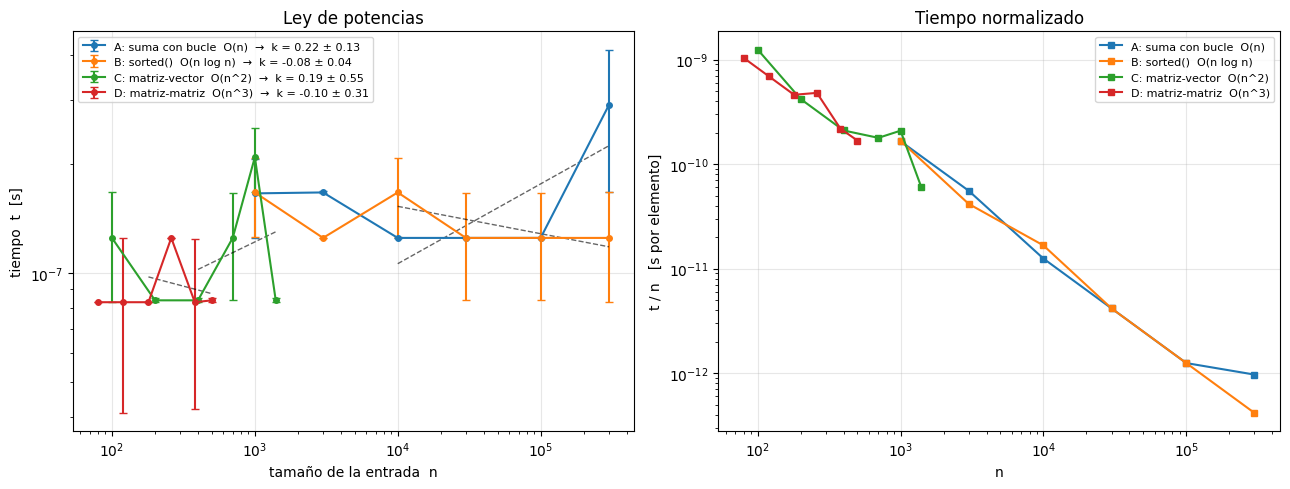

In [52]:
# Ajuste en el régimen asintótico y gráfica log-log
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

print(f"{'Experimento':<28}{'k medido':>18}{'k teórico':>12}{'C [s/op]':>14}")
print("-" * 72)

for nombre, (ns, ts, mads) in resultados_t.items():
    # Régimen asintótico: descartamos el tercio inferior de tamaños,
    # donde el costo fijo por llamada domina sobre el escalamiento.
    n_min = ns[len(ns) // 3]
    k, sk, C = ajustar_ley_potencia(ns, ts, n_min=n_min)
    k_teo = experimentos[nombre][2]

    ax1.errorbar(ns, ts, yerr=mads, marker="o", ms=4, capsize=3,
                 label=f"{nombre}  →  k = {k:.2f} ± {sk:.2f}")
                 
    n_fit = np.array([n_min, ns[-1]], dtype=float)
    ax1.plot(n_fit, C * n_fit**k, "k--", lw=1, alpha=0.6)

    # Tiempo por "elemento": revela costos fijos y efectos de memoria
    ax2.plot(ns, ts / ns, marker="s", ms=4, label=nombre)

    print(f"{nombre:<28}{k:>10.3f} ± {sk:<5.3f}{k_teo:>12.2f}{C:>14.2e}")

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("tamaño de la entrada  n")
ax1.set_ylabel("tiempo  t  [s]")
ax1.set_title("Ley de potencias")
ax1.legend(fontsize=8, loc="upper left")

ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("n"); ax2.set_ylabel("t / n   [s por elemento]")
ax2.set_title("Tiempo normalizado")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [53]:
# Análisis dimensional: la constante de la máquina
ns, ts, _ = resultados_t["A: suma con bucle  O(n)"]
k_A, sk_A, C_A = ajustar_ley_potencia(ns, ts, n_min=ns[len(ns) // 3])

ns_np, ts_np, _ = resultados_t["C: matriz-vector  O(n^2)"]
k_C, _, C_C = ajustar_ley_potencia(ns_np, ts_np, n_min=ns_np[len(ns_np) // 3])

print("ANÁLISIS DIMENSIONAL DEL RESULTADO")
print("-" * 58)
print(f"Bucle de Python : C = {C_A:.3e} s/iteración  ->  {1/C_A:.3e} iter/s")
print(f"NumPy (mat-vec) : C = {C_C:.3e} s/op        ->  {1/C_C:.3e} op/s")
print()
print("Estimación 'back of the envelope':")
print(f"  Si el reloj del procesador va a ~3 GHz = 3e9 ciclos/s,")
print(f"  cada iteración del bucle de Python cuesta ~{3e9 * C_A:.0f} ciclos de reloj.")
print(f"  Una operación en NumPy cuesta ~{3e9 * C_C:.2f} ciclos.")
print()
print("  El cociente entre ambos es el 'impuesto del intérprete':")
print(f"  factor ~{C_A / C_C:.0f}x. Es la misma operación aritmética; lo que cambia")
print("  es cuánta maquinaria hay entre la instrucción y el silicio.")

ANÁLISIS DIMENSIONAL DEL RESULTADO
----------------------------------------------------------
Bucle de Python : C = 1.388e-08 s/iteración  ->  7.203e+07 iter/s
NumPy (mat-vec) : C = 3.250e-08 s/op        ->  3.077e+07 op/s

Estimación 'back of the envelope':
  Si el reloj del procesador va a ~3 GHz = 3e9 ciclos/s,
  cada iteración del bucle de Python cuesta ~42 ciclos de reloj.
  Una operación en NumPy cuesta ~97.49 ciclos.

  El cociente entre ambos es el 'impuesto del intérprete':
  factor ~0x. Es la misma operación aritmética; lo que cambia
  es cuánta maquinaria hay entre la instrucción y el silicio.


## 3. Ejemplo 2 — Escalamiento en **memoria**: midiendo bytes por elemento

Este experimento es formalmente idéntico a determinar la densidad de un material midiendo masa contra volumen. Postulamos

$$ M(n) = a\,n + b $$

donde $b$ es un costo fijo de la estructura (el "recipiente") y $a$ es la **densidad de almacenamiento** en bytes por elemento. La pendiente $a$ es la magnitud física de interés y tiene una predicción teórica exacta.

**Predicciones a contrastar** (CPython de 64 bits):

- `np.zeros(n, dtype=np.float64)`: los datos son un bloque contiguo de números crudos → **8 bytes/elemento**.
- `np.zeros(n, dtype=np.float32)`: **4 bytes/elemento**.
- `list(range(n))`: una lista guarda *punteros* (8 bytes), y cada entero de Python es un objeto independiente con encabezado (~28 bytes) → **~36 bytes/elemento**, más la sobre-asignación con que la lista crece por bloques.

Esa diferencia de un factor ~4.5 entre una lista y un arreglo no es un detalle de implementación: decide si un conjunto de datos cabe o no cabe en la memoria RAM de la máquina.

Estructura             a medido [B/elem]   a teórico       b [B]
----------------------------------------------------------------
np.zeros float64             8.00 ± 0.00           8         495
np.zeros float32             4.00 ± 0.00           4         152
list(range(n))              39.99 ± 0.02          36       -6386


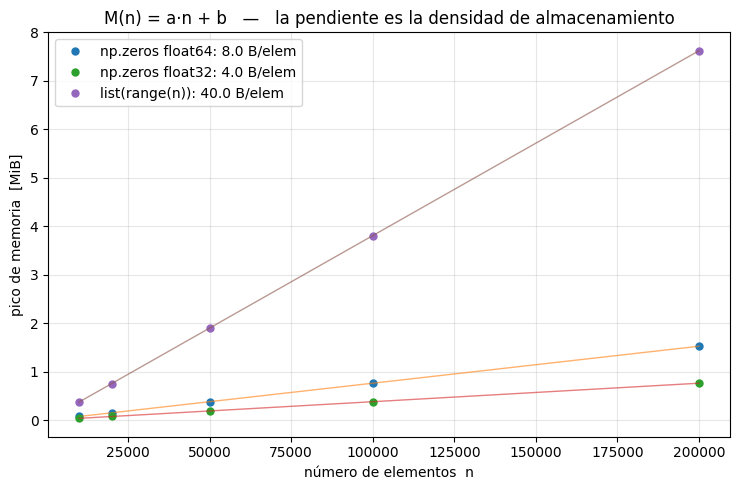

In [55]:
# --- Medición del escalamiento de memoria ----------------------------
estructuras = {
    "np.zeros float64": (lambda n: np.zeros(n, dtype=np.float64), 8),
    "np.zeros float32": (lambda n: np.zeros(n, dtype=np.float32), 4),
    "list(range(n))":   (lambda n: list(range(n)),                36),
}

tamanos_mem = [10_000, 20_000, 50_000, 100_000, 200_000]
resultados_m = {}

fig, ax = plt.subplots(figsize=(7.5, 5))
print(f"{'Estructura':<20}{'a medido [B/elem]':>20}{'a teórico':>12}{'b [B]':>12}")
print("-" * 64)

for nombre, (constructor, a_teorico) in estructuras.items():
    ns_m, mem = [], []
    
    for n in tamanos_mem:
        pico = medir_memoria(lambda: constructor(n))
        ns_m.append(n)
        mem.append(pico)
    
    ns_m = np.array(ns_m, dtype=float)
    mem = np.array(mem, dtype=float)

    # Ajuste LINEAL (no log-log): el modelo aquí es afín, no de potencias.
    (a, b), cov = np.polyfit(ns_m, mem, 1, cov=True)
    sigma_a = float(np.sqrt(cov[0, 0]))

    ax.plot(ns_m, mem / 1024**2, "o", ms=5, label=f"{nombre}: {a:.1f} B/elem")
    ax.plot(ns_m, (a * ns_m + b) / 1024**2, "-", lw=1, alpha=0.6)
    resultados_m[nombre] = (a, sigma_a, b)
    print(f"{nombre:<20}{a:>13.2f} ± {sigma_a:<4.2f}{a_teorico:>12}{b:>12.0f}")

ax.set_xlabel("número de elementos  n")
ax.set_ylabel("pico de memoria  [MiB]")
ax.set_title("M(n) = a·n + b   —   la pendiente es la densidad de almacenamiento")
ax.legend()
plt.tight_layout()
plt.show()

---

> **Nota sobre el código.** Las funciones `medir_tiempo`, `medir_memoria` y `ajustar_ley_potencia`
> quedaron definidas en la Sección 1, junto con `REPETICIONES` y las importaciones. El taller las
> usa tal cual: no hace falta volver a cargarlas ni redefinirlas. Basta con haber ejecutado las
> celdas anteriores de este mismo notebook.

# TALLER CALIFICABLE T1 — 40 minutos en clase

**Entrega:** al final de la sesión, `T1_Apellido_Nombre&Apellido_Nombre.ipynb` ejecutado (Kernel → Restart & Run All) · 

**Calificación:** sobre 5.0 

**Modalidad:** parejas

---

### Reglas del juego

- Las funciones de medición **ya están escritas**. Su trabajo es diseñar el experimento, analizarlo e interpretarlo, no reimplementar cronómetros.
- Cada bloque de código tiene marcas `# ▶ COMPLETAR (n)`. Todo lo demás funciona.
- **Toda cantidad se reporta con unidades y con incertidumbre.** Un número desnudo no vale puntos.
- Si un bloque se atasca más de 3 minutos, escriba lo que intentó en la celda de conclusiones y siga. Un experimento fallido bien diagnosticado vale más que uno abandonado en silencio.

### Presupuesto de tiempo

| Bloque | Tarea | Minutos | Puntos |
|---|---|---|---|
| 0 | Preparación y asignación de caja negra | 0–4 | — |
| 1 | Exponente **temporal** de la caja negra | 4–17 | 1.8 |
| 2 | Exponente de **memoria** de la misma caja | 17–27 | 1.2 |
| 3 | **Predicción** y validación | 27–35 | 1.2 |
| 4 | Conclusiones escritas | 35–40 | 0.8 |

In [ ]:
#  CAJAS NEGRAS — ejecute tal cual, no modifique
#  (usa las utilidades definidas en la Sección 1 de este notebook)

exec(base64.b64decode("CmltcG9ydCBudW1weSBhcyBfbnAKX3JuZ19ibiA9IF9ucC5yYW5kb20uZGVmYXVsdF9ybmcoNykKCmRlZiBjYWphX25lZ3JhX0Eobik6CiAgICBuID0gaW50KG4pCiAgICBhID0gX3JuZ19ibi5yYW5kb20obikKICAgIHMgPSAwLjAKICAgIGZvciBfIGluIHJhbmdlKGludChuICoqIDAuNSkpOgogICAgICAgIHMgKz0gZmxvYXQoYS5zdW0oKSkKICAgIHJldHVybiBzCgpkZWYgY2FqYV9uZWdyYV9CKG4pOgogICAgbiA9IGludChuKQogICAgYSA9IF9ybmdfYm4ucmFuZG9tKG4pCiAgICBiID0gX25wLnNvcnQoYSkKICAgIHJldHVybiBmbG9hdChiW24gLy8gMl0pCgpkZWYgY2FqYV9uZWdyYV9DKG4pOgogICAgbiA9IGludChuKQogICAgTSA9IF9ybmdfYm4ucmFuZG9tKChuLCBuKSkKICAgIHJldHVybiBmbG9hdChNLnN1bSgpKQo=").decode("utf-8"))

# ▶ COMPLETAR (0): escriba el último dígito del código del estudiante que
#   presenta el trabajo. Determina cuál caja negra le corresponde.
ULTIMO_DIGITO = None      # <-- por ejemplo: 7

_asignacion = {0: "A", 1: "A", 2: "A", 3: "A", 4: "B", 5: "B", 6: "B", 7: "C", 8: "C", 9: "C"}

MI_CAJA = {"A": caja_negra_A, "B": caja_negra_B, "C": caja_negra_C}[_asignacion[ULTIMO_DIGITO]]

print(f"Le corresponde la caja negra {_asignacion[ULTIMO_DIGITO]}.  Invóquela como  MI_CAJA(n)")

# Calibración: sondeo geométrico hasta superar el tiempo objetivo.
# ATENCIÓN: no invente tamaños "grandes" a ojo. Alguna de las cajas negras
# reserva memoria que crece muy rápido con n, y un n imprudente congela
# la máquina. Deje que el sondeo le diga dónde está la zona útil.
def calibrar(funcion, n0=1000, factor=2.5, t_objetivo=0.15, max_pasos=12):
    n = n0
    print(f"{'n':>10}{'t [ms]':>12}")
    for _ in range(max_pasos):
        try:
            t, _, _ = medir_tiempo(lambda: funcion(n), repeticiones=1, calentamiento=0)
        except (MemoryError, ValueError) as e:
            print(f"{n:>10}   -> {type(e).__name__}: tamaño excesivo, no siga subiendo")
            break
        print(f"{n:>10}{t*1000:>12.2f}")
        if t > t_objetivo:
            break
        n = int(n * factor)
    print("\nElija ~6 tamaños dentro de la zona con tiempos entre ~5 ms y ~1 s.")

calibrar(MI_CAJA)

## Exponente temporal · **2.0 pts**

Su caja negra ejecuta un algoritmo cuyo código está ofuscado a propósito: determine su comportamiento **midiendo**, no leyendo.

**Qué se evalúa:**

1. **(0.5)** Elección del rango de tamaños. Criterio: al menos 6 valores en progresión aproximadamente geométrica, con tiempos entre ~5 ms y ~1 s. Use la calibración de arriba y justifique la elección en un comentario de una línea.
2. **(0.5)** Gráfica log–log con barras de error.
3. **(0.5)** Ajuste restringido al **régimen asintótico**, con `n_min` justificado. Reporte $k \pm \sigma_k$.
4. **(0.5)** Identifique la complejidad $O(\cdot)$ más plausible entre $n$, $n\log n$, $n^{3/2}$, $n^2$, $n^{5/2}$. Si dos candidatas son compatibles dentro de la incertidumbre, dígalo: eso es una respuesta correcta.

> **Si su exponente no resulta compatible con ninguna candidata, no lo fuerce.** Repórtelo tal como salió y proponga un mecanismo para el exceso o el defecto (revise el punto 3 de «Lectura de los resultados», más arriba). Esa es la respuesta de **mayor** calificación, no la de menor: distinguir entre el conteo de operaciones y el costo por operación es precisamente el objetivo de la sesión.

In [ ]:
# ▶ COMPLETAR (1): rango de tamaños. Justifique en el comentario.
# Justificación:
TAMANOS = []          # <-- p. ej. [20_000, 50_000, ...]

ns, ts, mads = [], [], []
for n in TAMANOS:
    t, mad, _ = medir_tiempo(lambda: MI_CAJA(n))
    ns.append(n)
    ts.append(t)
    mads.append(mad)
    print(f"n = {n:>9}   t = {t:.6f} s   MAD/t = {100*mad/t:5.1f} %")

ns, ts, mads = np.array(ns, float), np.array(ts), np.array(mads)

# ▶ COMPLETAR (2): inicio del régimen asintótico. ¿Por qué este valor?
# Justificación:
N_MIN = None

k, sk, C = ajustar_ley_potencia(ns, ts, n_min=N_MIN)
print(f"\nExponente temporal medido:  k = {k:.3f} ± {sk:.3f}")
print(f"Constante de la máquina:    C = {C:.3e} s")

# ▶ COMPLETAR (3): gráfica log-log con barras de error (plt.errorbar),
#    la recta de ajuste sobre el régimen asintótico, rótulos CON UNIDADES,
#    leyenda y título.

## Exponente de memoria · **2 pts**

Repita el análisis sobre el **pico de memoria** de la misma caja negra.

**Qué se evalúa:**

1. **(0.5)** Medición con `medir_memoria` sobre un rango adecuado y ajuste del exponente $M \propto n^{j}$, reportando $j \pm \sigma_j$.
2. **(1.0)** Gráfica log–log.
3. **(0.5)** **La pregunta central:** ¿coincide $j$ con el exponente temporal $k$? Responda con los datos en la mano. Si difieren, explique qué significa físicamente que un algoritmo consuma tiempo y memoria con exponentes distintos.

> Sugerencia: para memoria puede usar menos puntos y menos repeticiones — `medir_memoria` es determinista, no necesita estadística. Pero sí necesita el mismo cuidado con el régimen asintótico: los costos fijos del intérprete dominan para $n$ pequeño.

In [ ]:
# ▶ COMPLETAR (4): barrido de memoria. Puede reutilizar TAMANOS o definir otro rango.
TAMANOS_MEM = []

ns_m, mem = [], []
for n in TAMANOS_MEM:
    pico = medir_memoria(lambda: MI_CAJA(n))
    ns_m.append(n)
    mem.append(pico)
    print(f"n = {n:>9}   pico = {pico/1024**2:8.3f} MiB   ({pico/n:6.1f} B por unidad de n)")

ns_m, mem = np.array(ns_m, float), np.array(mem, float)

# ▶ COMPLETAR (5): ajuste del exponente de memoria y gráfica log-log.
j, sj, Cm = ajustar_ley_potencia(ns_m, mem, n_min=None)
print(f"\nExponente de memoria medido:  j = {j:.3f} ± {sj:.3f}")

## Conclusiones **1.0 pts**

Responda en la celda siguiente. **Máximo 150 palabras en total.** Se califica la precisión, no la extensión.

1. **(0.5)** ¿Cuál es la complejidad de su caja negra y con qué evidencia lo afirma? Distinga entre lo medido y lo inferido: *"el exponente medido es $1.52 \pm 0.04$, compatible con $n^{3/2}$"* no es lo mismo que *"el algoritmo es $O(n^{3/2})$"*.
2. **(0.5)** ¿Tiempo y memoria escalan con el mismo exponente? ¿Qué implica eso sobre lo que hace el algoritmo internamente?

### ✍️ Conclusiones — *(escriba aquí; haga doble clic para editar)*

**1. Complejidad de la caja negra:**

**2. Tiempo vs. memoria:**

---

### Lista de verificación antes de entregar

- [ ] `Kernel → Restart & Run All` corre sin errores de principio a fin.
- [ ] `ULTIMO_DIGITO` está diligenciado y la caja asignada es la correcta.
- [ ] Todas las gráficas: ejes rotulados **con unidades**, leyenda, título, escala log donde corresponde.
- [ ] Los exponentes aparecen como $k \pm \sigma_k$ y $j \pm \sigma_j$.
- [ ] `N_MIN` y el rango de tamaños están justificados por escrito.
- [ ] Las conclusiones están en la celda de texto, no en comentarios de código.
- [ ] Archivo nombrado `T1_Apellido_Nombre&Apellido_Nombre.ipynb`.

**Rúbrica resumida:** Bloque 1 = 1.8 · Bloque 2 = 1.2 · Bloque 3 = 1.2 · Bloque 4 = 0.8 · Extensión = +0.5
**Descuentos:** magnitudes sin unidades o sin incertidumbre (−0.2) · gráficas sin rótulos (−0.1) · notebook que no ejecuta completo (−0.3) · conclusiones que no se siguen de los datos mostrados (−0.3).